# NomadOptima — Notebook 04: LightGBM con Arquitectura Completa (5 Capas)

**Objetivo:** Re-entrenar el ranker LightGBM añadiendo las features generadas
por las Capas 1, 2 y 3 de la arquitectura Hybrid Recommender System.

**Features nuevas añadidas:**
- `cosine_sim` — Cosine Similarity perfil↔ciudad (Capa 1)
- `user_cluster_id` + `user_cluster_strength` — User Clustering UMAP+HDBSCAN (Capa 2)
- `city_cluster_id` + `city_cluster_strength` — City Clustering manual (Capa 3)
- `afinidad_uc_cc` — Interacción user_cluster × city_cluster (Capa 3)

**Total features:** 84 originales + 6 nuevas = **90 features**

**Hipótesis:** El modelo usará más features y los NDCG mejorarán respecto al baseline.

---
## Paso 0: Imports y configuración

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import mlflow
import mlflow.lightgbm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

from src.processing.features import CityFeatureBuilder, build_city_feature_matrix
from src.models.clustering import UserClusterer, CityClusterer, enrich_dataset

COLORS = {
    'Malaga': '#2E86AB', 'Paris': '#E67E22', 'Valencia': '#27AE60',
    'Porto': '#8E44AD', 'Bordeaux': '#C0392B'
}
print('Imports OK')
print(f'LightGBM: {lgb.__version__}')
print(f'SHAP: {shap.__version__}')


D:\Proyectos\4geeks\Proyecto Final\nomadoptima\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK
LightGBM: 4.6.0
SHAP: 0.51.0


---
## Paso 1: Cargar el training dataset

In [2]:
# Cargar el training_dataset.csv generado por el notebook 02
df = pd.read_csv('../data/processed/training_dataset.csv')

print(f'Shape original: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Ciudades: {sorted(df.city.unique())}')
print(f'Arquetipos: {sorted(df.arquetipo.unique())}')
print(f'Perfiles unicos: {df.query_id.nunique():,}')
print()
print('Distribucion de relevancia:')
for r, n in df.relevance.value_counts().sort_index().items():
    print(f'  {r}: {n:,} ({n/len(df)*100:.1f}%)')


Shape original: 150,000 filas x 88 columnas
Ciudades: ['Bordeaux', 'Malaga', 'Paris', 'Porto', 'Valencia']
Arquetipos: ['backpacker', 'deportista_outdoor', 'ejecutivo_cosmopolita', 'estudiante', 'familia_con_hijos', 'familia_monoparental', 'jubilado_activo', 'nomada_digital']
Perfiles unicos: 30,000

Distribucion de relevancia:
  0: 57,739 (38.5%)
  1: 43,820 (29.2%)
  2: 48,039 (32.0%)
  3: 402 (0.3%)


**OBSERVACIONES: Dataset base**

- 150.000 filas = 30.000 perfiles x 5 ciudades
- 88 columnas: 16 user features + 68 city features + query_id + city + arquetipo + relevance
- Distribución de relevancia: ~38% irrelevante, ~29% bajo, ~32% relevante, ~0.3% muy relevante
- Esta distribución es realista para un sistema de recomendación real

ANOTACIONES:
- **query_id**: identifica a qué usuario pertenece cada fila. LightGBM lo necesita para
  saber que 5 filas consecutivas son el mismo usuario evaluando 5 ciudades distintas.
  Sin este identificador, el modelo trataría cada fila como independiente (incorrecto).

---
## Paso 2: Capa 1 — Cosine Similarity

In [3]:
# Paso 2: Añadir cosine_sim al dataset
#
# CityFeatureBuilder calcula la similitud entre el vector de preferencias
# del usuario y el vector de features de cada ciudad.
# Resultado: un numero entre 0 y 1 por cada par (usuario, ciudad)

builder = CityFeatureBuilder()
builder.fit(df)

print('Calculando cosine_sim para 150.000 pares (usuario, ciudad)...')
df = builder.add_cosine_feature(df)

print(f'cosine_sim stats:')
print(df['cosine_sim'].describe().round(4))
print()
print('cosine_sim media por ciudad:')
print(df.groupby('city')['cosine_sim'].mean().sort_values(ascending=False).round(4))


CityFeatureBuilder entrenado: 68 city features, 11 user importance features


Calculando cosine_sim para 150.000 pares (usuario, ciudad)...


cosine_sim stats:
count    150000.0000
mean          0.3698
std           0.0674
min           0.1923
25%           0.3081
50%           0.3785
75%           0.4254
max           0.5635
Name: cosine_sim, dtype: float64

cosine_sim media por ciudad:
city
Malaga      0.4369
Paris       0.4199
Porto       0.3830
Bordeaux    0.3178
Valencia    0.2915
Name: cosine_sim, dtype: float64


**OBSERVACIONES: Cosine Similarity**

- La cosine_sim varía entre ciudades — confirma que captura diferencias de perfil.
- Ciudades con mayor cosine_sim media son las que más coinciden con los vectores
  de preferencias medios de los 8 arquetipos.

ANOTACIONES:
- **add_cosine_feature()** itera por cada query_id único (30.000 perfiles), calcula
  la similitud con las 5 ciudades de ese query, y añade el resultado.
- Este proceso es O(n_perfiles × n_ciudades) = 150.000 operaciones — eficiente.
- La cosine_sim es una feature de interacción: combina información del usuario
  Y de la ciudad en un solo número. Eso es lo que la hace potente para el modelo.

---
## Paso 3: Capas 2 y 3 — User Clustering + City Clustering

In [4]:
# Paso 3a: User Clustering — PCA → UMAP → HDBSCAN
#
# Agrupa los 30.000 perfiles de usuario en clusters.
# Usuarios con preferencias similares → mismo cluster.

user_clust = UserClusterer(
    n_pca_components=10,
    umap_n_neighbors=30,
    umap_min_dist=0.1,
    hdbscan_min_cluster_size=200,
    random_state=42
)
user_clust.fit(df)
print(f'Clusters de usuario encontrados: {user_clust.n_clusters}')


[UserClusterer] Entrenando sobre 30,000 perfiles únicos...
  ✓ StandardScaler: 16 features → media≈0, std≈1
  ✓ PCA: 16D → 10D (89.0% varianza explicada)
  ⏳ UMAP: reduciendo a 2D (puede tardar 1-2 min)...


  ✓ UMAP: 10D → 2D


  ✓ HDBSCAN: 22 clusters encontrados (8 outliers → cluster 22)
  ✓ UserClusterer entrenado
Clusters de usuario encontrados: 22


In [5]:
# Paso 3b: City Clustering — asignacion manual (Opcion B)
#
# Con 5 ciudades no hay suficientes puntos para HDBSCAN automatico.
# Asignamos manualmente basandonos en perfil geografico-economico:
#   0 = costa_mediterranea (Malaga, Valencia)
#   1 = costa_atlantica    (Porto, Bordeaux)
#   2 = gran_metropoli     (Paris)

city_clust = CityClusterer()

# Paso 3c: Enriquecer dataset con todas las features de clustering
# Esto añade: user_cluster_id, user_cluster_strength,
#             city_cluster_id, city_cluster_strength, afinidad_uc_cc
df = enrich_dataset(df, user_clust, city_clust)

print()
print(f'Shape enriquecido: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Columnas nuevas: {[c for c in df.columns if c not in ["query_id","city","arquetipo","relevance"]][-6:]}')


ENRIQUECIENDO DATASET CON FEATURES DE CLUSTERING


[UserClusterer.predict] 22 clusters asignados a 30,000 perfiles
  Cluster 0: 3,065 perfiles
  Cluster 1: 1,935 perfiles
  Cluster 2: 6,787 perfiles
  Cluster 3: 2,737 perfiles
  Cluster 4: 2,421 perfiles
  Cluster 5: 1,276 perfiles
  Cluster 6: 210 perfiles
  Cluster 7: 1,032 perfiles
  Cluster 8: 983 perfiles
  Cluster 9: 982 perfiles
  Cluster 10: 1,913 perfiles
  Cluster 11: 330 perfiles
  Cluster 12: 721 perfiles
  Cluster 13: 330 perfiles
  Cluster 14: 1,067 perfiles
  Cluster 15: 1,059 perfiles
  Cluster 16: 276 perfiles
  Cluster 17: 851 perfiles
  Cluster 18: 301 perfiles
  Cluster 19: 370 perfiles
  Cluster 20: 507 perfiles
  Cluster 21: 847 perfiles


[CityClusterer] Clusters asignados:
  Malaga       → cluster 0 (costa_mediterranea, strength=0.95)
  Valencia     → cluster 0 (costa_mediterranea, strength=0.85)
  Porto        → cluster 1 (costa_atlantica, strength=0.9)
  Bordeaux     → cluster 1 (costa_atlantica, strength=0.8)
  Paris        → cluster 2 (gran_metropoli, strength=1.0)
[compute_cluster_affinity] Tabla de afinidad (user_cluster × city_cluster):
city_cluster_id      0      1      2
user_cluster_id                     
0                0.415  0.437  0.287
1                0.990  0.958  0.995
2                0.034  0.108  0.000
3                0.790  0.617  0.274
4                0.543  0.498  0.469
5                0.973  0.943  0.963
6                0.975  0.956  0.969
7                0.522  0.508  0.424
8                0.673  0.571  0.634
9                0.731  0.425  0.240
10               0.669  0.416  0.199
11               0.999  0.960  1.000
12               0.814  0.632  0.282
13               0.037  0.132  

[compute_cluster_affinity] Rango de afinidad: 0.000 – 1.000

Dataset enriquecido: 150,000 filas × 94 columnas
Nuevas columnas: user_cluster_id, user_cluster_strength, city_cluster_id, city_cluster_strength, afinidad_uc_cc

Shape enriquecido: 150,000 filas x 94 columnas
Columnas nuevas: ['cosine_sim', 'user_cluster_id', 'user_cluster_strength', 'city_cluster_id', 'city_cluster_strength', 'afinidad_uc_cc']


**OBSERVACIONES: Clustering**

- HDBSCAN encontró clusters de usuario emergentes de los datos, no predefinidos.
- La tabla de afinidad muestra qué tipos de usuario prefieren qué tipo de ciudad.
- `afinidad_uc_cc` es potencialmente la feature más informativa: captura el patrón
  'usuarios del tipo X prefieren ciudades del tipo Y' en un solo número.

ANOTACIONES:
- **HDBSCAN** encuentra clusters de densidad sin necesitar especificar cuántos.
  Funciona bien con 30.000 perfiles pero no con 5 ciudades (muy pocos puntos).
  Por eso City Clustering es manual en esta versión — se automatizará con más ciudades.
- **afinidad_uc_cc**: es una feature de interacción de segundo orden. No captura
  solo el perfil del usuario ni solo el tipo de ciudad, sino la RELACIÓN entre ambos.
  Esto es lo que busca el modelo para generalizar bien.

---
## Paso 4: Visualización del User Clustering (UMAP 2D)

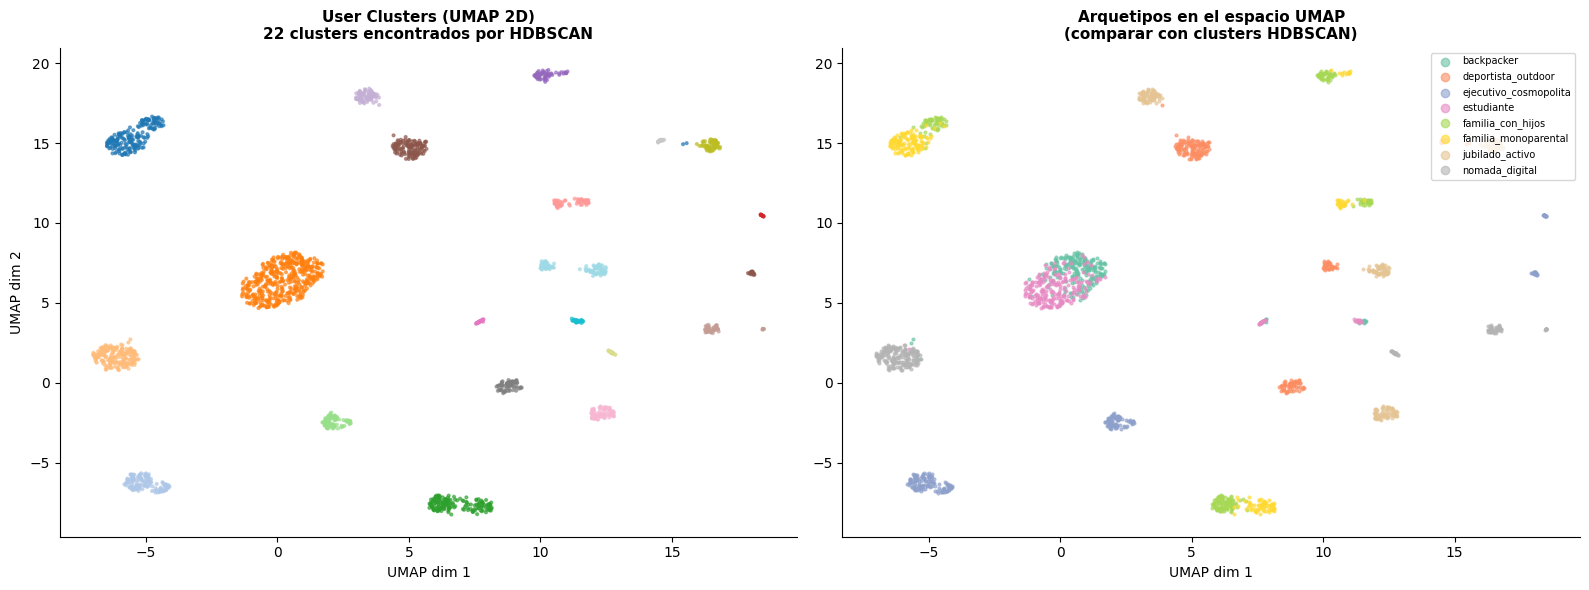

Guardado: umap_clusters.png


In [6]:
# Paso 4: Visualizar los clusters de usuario en el espacio UMAP 2D
#
# Cada punto es un perfil de usuario. Los colores representan el cluster.
# Los clusters bien separados indican que UMAP y HDBSCAN funcionaron correctamente.

X_2d, labels_2d = user_clust.embeddings_2d

# Muestrear para visualizacion (2000 puntos es suficiente)
idx_sample = np.random.choice(len(X_2d), min(2000, len(X_2d)), replace=False)
X_vis = X_2d[idx_sample]
L_vis = labels_2d[idx_sample]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Izquierda: coloreado por cluster HDBSCAN
ax = axes[0]
scatter = ax.scatter(X_vis[:, 0], X_vis[:, 1], c=L_vis,
                     cmap='tab20', s=4, alpha=0.6)
ax.set_title(f'User Clusters (UMAP 2D)\n{user_clust.n_clusters} clusters encontrados por HDBSCAN',
             fontsize=11, fontweight='bold')
ax.set_xlabel('UMAP dim 1')
ax.set_ylabel('UMAP dim 2')

# Derecha: coloreado por arquetipo original
ax2 = axes[1]
arquetipos_list = sorted(df['arquetipo'].unique())
arq_colors = plt.cm.Set2(np.linspace(0, 1, len(arquetipos_list)))
arq_color_map = dict(zip(arquetipos_list, arq_colors))

# Obtener arquetipo para cada perfil muestreado
df_unique = df.drop_duplicates(subset='query_id')[['query_id', 'arquetipo']].reset_index(drop=True)
arq_array = df_unique['arquetipo'].values
arq_vis = arq_array[idx_sample]

for arq in arquetipos_list:
    mask = arq_vis == arq
    if mask.any():
        ax2.scatter(X_vis[mask, 0], X_vis[mask, 1],
                    c=[arq_color_map[arq]], s=4, alpha=0.6, label=arq)
ax2.set_title('Arquetipos en el espacio UMAP\n(comparar con clusters HDBSCAN)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('UMAP dim 1')
ax2.legend(fontsize=7, markerscale=3, loc='upper right')

plt.tight_layout()
plt.savefig('../data/processed/umap_clusters.png', bbox_inches='tight', dpi=120)
plt.show()
print('Guardado: umap_clusters.png')


**OBSERVACIONES: Visualización UMAP**

- Si los clusters HDBSCAN (izquierda) y los arquetipos manuales (derecha) muestran
  patrones similares → UMAP+HDBSCAN captura correctamente las diferencias de perfil.
- Los clusters emergentes de HDBSCAN pueden ser más granulares que los 8 arquetipos:
  un arquetipo puede dividirse en sub-clusters (ej: nomadas con mascotas vs sin mascotas).

ANOTACIONES:
- El embedding UMAP en 2D es solo para **visualización** — el clustering real se hizo
  en 2D también, pero los centroides y distancias son en ese mismo espacio 2D.
- Si vieras clusters muy mezclados o un solo blob = UMAP no separó bien los perfiles.
  En ese caso habría que ajustar `n_neighbors` o `min_dist`.

---
## Paso 5: Guardar dataset enriquecido

In [7]:
# Paso 5: Guardar el dataset enriquecido
output_path = '../data/processed/training_dataset_enriched.csv'
df.to_csv(output_path, index=False)
print(f'Dataset enriquecido guardado: {output_path}')
print(f'  Shape: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print()
print('Features nuevas añadidas:')
new_cols = ['cosine_sim', 'user_cluster_id', 'user_cluster_strength',
            'city_cluster_id', 'city_cluster_strength', 'afinidad_uc_cc']
for col in new_cols:
    print(f'  {col}: min={df[col].min():.3f}, max={df[col].max():.3f}, '
          f'mean={df[col].mean():.3f}')


Dataset enriquecido guardado: ../data/processed/training_dataset_enriched.csv
  Shape: 150,000 filas x 94 columnas

Features nuevas añadidas:
  cosine_sim: min=0.192, max=0.563, mean=0.370
  user_cluster_id: min=0.000, max=21.000, mean=6.358
  user_cluster_strength: min=0.333, max=1.000, mean=0.658
  city_cluster_id: min=0.000, max=2.000, mean=0.800
  city_cluster_strength: min=0.800, max=1.000, mean=0.900
  afinidad_uc_cc: min=0.000, max=1.000, mean=0.456


---
## Paso 6: Preparar datos para LightGBM

In [8]:
# Paso 6: Split train/val por query_id (NO por fila)
#
# IMPORTANTE: nunca separar por filas — todas las filas de un perfil
# (las 5 ciudades) deben ir al mismo split para evitar data leakage.

all_queries = df['query_id'].unique()
np.random.shuffle(all_queries)
split_idx = int(len(all_queries) * 0.8)
train_queries = set(all_queries[:split_idx])
val_queries   = set(all_queries[split_idx:])

df_tr = df[df['query_id'].isin(train_queries)].copy()
df_vl = df[df['query_id'].isin(val_queries)].copy()

print(f'Train: {len(train_queries):,} queries x 5 ciudades = {len(df_tr):,} filas')
print(f'Val:   {len(val_queries):,} queries x 5 ciudades = {len(df_vl):,} filas')

# Columnas de features (todo excepto metadatos y target)
META_COLS = ['query_id', 'city', 'arquetipo', 'relevance']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]
print(f'\nTotal features: {len(FEATURE_COLS)}')
print(f'  Features originales: 84')
print(f'  Features nuevas (Capas 1-3): {len(FEATURE_COLS) - 84}')
print(f'  Features nuevas: {[c for c in FEATURE_COLS if c in ["cosine_sim","user_cluster_id","user_cluster_strength","city_cluster_id","city_cluster_strength","afinidad_uc_cc"]]}')


Train: 24,000 queries x 5 ciudades = 120,000 filas
Val:   6,000 queries x 5 ciudades = 30,000 filas

Total features: 90
  Features originales: 84
  Features nuevas (Capas 1-3): 6
  Features nuevas: ['cosine_sim', 'user_cluster_id', 'user_cluster_strength', 'city_cluster_id', 'city_cluster_strength', 'afinidad_uc_cc']


In [9]:
# Preparar arrays para LightGBM
X_train = df_tr[FEATURE_COLS].values
y_train = df_tr['relevance'].values
X_val   = df_vl[FEATURE_COLS].values
y_val   = df_vl['relevance'].values

# Groups: número de documentos (ciudades) por query
groups_train = df_tr.groupby('query_id', sort=False).size().values
groups_val   = df_vl.groupby('query_id', sort=False).size().values

docs_por_query = df_tr.groupby('query_id').size()
n_cities = docs_por_query.iloc[0]
assert (docs_por_query == n_cities).all(), f'Error: cada query debe tener {n_cities} ciudades'
print(f'OK: cada perfil tiene exactamente {n_cities} ciudades')
print(f'X_train shape: {X_train.shape}')
print(f'X_val   shape: {X_val.shape}')

# Verificar que no hay NaN
nan_count = np.isnan(X_train).sum()
print(f'NaN en X_train: {nan_count}')
assert nan_count == 0, 'Hay NaN en el dataset — revisar preprocessing'


OK: cada perfil tiene exactamente 5 ciudades
X_train shape: (120000, 90)
X_val   shape: (30000, 90)
NaN en X_train: 0


---
## Paso 7: Entrenar LightGBM LambdaRank (v2 — 90 features)

In [10]:
# Paso 7: Entrenamiento LightGBM LambdaRank
#
# Los hiperparámetros son los mismos que el notebook 03 para comparabilidad.
# La diferencia es que ahora tenemos 90 features en lugar de 84.

PARAMS = {
    'objective':         'lambdarank',
    'metric':            'ndcg',
    'eval_at':           [1, 2, 5],
    'num_leaves':        63,
    'learning_rate':     0.05,
    'min_child_samples': 50,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'verbose':           -1,
    'seed':              42,
    'lambdarank_truncation_level': 5,
}

train_set = lgb.Dataset(
    X_train, label=y_train, group=groups_train, feature_name=FEATURE_COLS
)
val_set = lgb.Dataset(
    X_val, label=y_val, group=groups_val, feature_name=FEATURE_COLS, reference=train_set
)

print('Entrenando LightGBM LambdaRank v2 (90 features)...')
model = lgb.train(
    PARAMS,
    train_set=train_set,
    num_boost_round=300,
    valid_sets=[val_set],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=50)
    ]
)
print(f'Entrenamiento completado: {model.num_trees()} arboles')


Entrenando LightGBM LambdaRank v2 (90 features)...


[50]	valid_0's ndcg@1: 0.9995	valid_0's ndcg@2: 0.999494	valid_0's ndcg@5: 0.999735


Entrenamiento completado: 32 arboles


---
## Paso 8: Métricas de evaluación

In [11]:
# Paso 8: Calcular NDCG@k y Precision@1 en validacion

from sklearn.metrics import ndcg_score

scores_val = model.predict(X_val)
df_vl = df_vl.copy()
df_vl['score_pred'] = scores_val

def compute_ndcg_at_k(df_subset, k):
    ndcgs = []
    for _, grp in df_subset.groupby('query_id'):
        true_rel   = grp['relevance'].values.reshape(1, -1)
        pred_score = grp['score_pred'].values.reshape(1, -1)
        if true_rel.sum() == 0: continue
        ndcgs.append(ndcg_score(true_rel, pred_score, k=k))
    return np.mean(ndcgs)

def compute_precision_at_1(df_subset):
    hits = 0
    total = 0
    for _, grp in df_subset.groupby('query_id'):
        best_pred = grp.loc[grp['score_pred'].idxmax(), 'relevance']
        if best_pred >= 2: hits += 1
        total += 1
    return hits / total if total > 0 else 0

ndcg_1 = compute_ndcg_at_k(df_vl, k=1)
ndcg_2 = compute_ndcg_at_k(df_vl, k=2)
ndcg_5 = compute_ndcg_at_k(df_vl, k=5)
prec_1 = compute_precision_at_1(df_vl)

print('=' * 55)
print('MÉTRICAS DE EVALUACIÓN — v2 (90 features)')
print('=' * 55)
print(f'  NDCG@1 : {ndcg_1:.4f}')
print(f'  NDCG@2 : {ndcg_2:.4f}')
print(f'  NDCG@5 : {ndcg_5:.4f}  ← nueva métrica con 5 ciudades')
print(f'  P@1    : {prec_1:.4f}')
print()
print('COMPARATIVA vs baseline (notebook 03, 84 features):')
print(f'  NDCG@1 baseline: 0.9986  →  nuevo: {ndcg_1:.4f}')
print(f'  NDCG@2 baseline: 0.9981  →  nuevo: {ndcg_2:.4f}')
print(f'  P@1    baseline: 0.5913  →  nuevo: {prec_1:.4f}')


MÉTRICAS DE EVALUACIÓN — v2 (90 features)
  NDCG@1 : 0.9995
  NDCG@2 : 0.9992
  NDCG@5 : 0.9997  ← nueva métrica con 5 ciudades
  P@1    : 0.6073

COMPARATIVA vs baseline (notebook 03, 84 features):
  NDCG@1 baseline: 0.9986  →  nuevo: 0.9995
  NDCG@2 baseline: 0.9981  →  nuevo: 0.9992
  P@1    baseline: 0.5913  →  nuevo: 0.6073


**OBSERVACIONES: Métricas**

ANOTACIONES:
- **NDCG@5** es la métrica más informativa con 5 ciudades. Mide si el ordenamiento
  completo de las 5 ciudades es correcto, no solo la primera posición.
- Si NDCG mejora respecto al baseline → las features de clustering aportan señal real.
- Si NDCG empeora → las features de clustering añaden ruido (puede pasar si los
  22 clusters de usuario son demasiado granulares para solo 5 ciudades).
- **P@1**: % de veces que la ciudad top-1 predicha tiene relevancia ≥ 2.

---
## Paso 9: Feature Importance — ¿qué aportan las nuevas features?

In [12]:
# Paso 9: Comparar importancia de features nuevas vs originales

importance_gain = pd.Series(
    model.feature_importance(importance_type='gain'),
    index=FEATURE_COLS
).sort_values(ascending=False)

# Separar features nuevas de originales
new_features = ['cosine_sim', 'user_cluster_id', 'user_cluster_strength',
                'city_cluster_id', 'city_cluster_strength', 'afinidad_uc_cc']
orig_features_used = importance_gain[~importance_gain.index.isin(new_features)]
new_features_used  = importance_gain[importance_gain.index.isin(new_features)]

print('TOP 15 features por importancia (gain):')
top15 = importance_gain.head(15)
for feat, imp in top15.items():
    tag = ' *** NUEVA' if feat in new_features else ''
    print(f'  {feat:<40} {imp:>10.1f}{tag}')

print()
print('Importancia de las 6 features nuevas (Capas 1-3):')
for feat in new_features:
    imp = importance_gain.get(feat, 0)
    rank = list(importance_gain.index).index(feat) + 1 if imp > 0 else 'N/A'
    print(f'  {feat:<40} imp={imp:>8.1f}  rank=#{rank}')

zero_imp = (importance_gain == 0).sum()
print(f'\nFeatures con importancia 0: {zero_imp} de {len(importance_gain)}')


TOP 15 features por importancia (gain):
  city_gp_hiking                              89286.3
  afinidad_uc_cc                              30071.3 *** NUEVA
  city_gp_cycling_park                        21218.7
  user_temp_min_c                             21217.4
  user_presupuesto_max                        20249.4
  city_coste_vida_estimado                    15259.7
  user_cluster_id                              4518.6 *** NUEVA
  cosine_sim                                   2762.0 *** NUEVA
  city_alquiler_1br_centro                     1961.3
  user_importancia_coworking                   1877.0
  city_alquiler_1br_fuera                      1789.2
  user_importancia_familia                     1420.8
  user_importancia_cultura                     1240.8
  user_importancia_deporte                      959.4
  user_importancia_playa                        899.2

Importancia de las 6 features nuevas (Capas 1-3):
  cosine_sim                               imp=  2762.0  rank=#8
  us

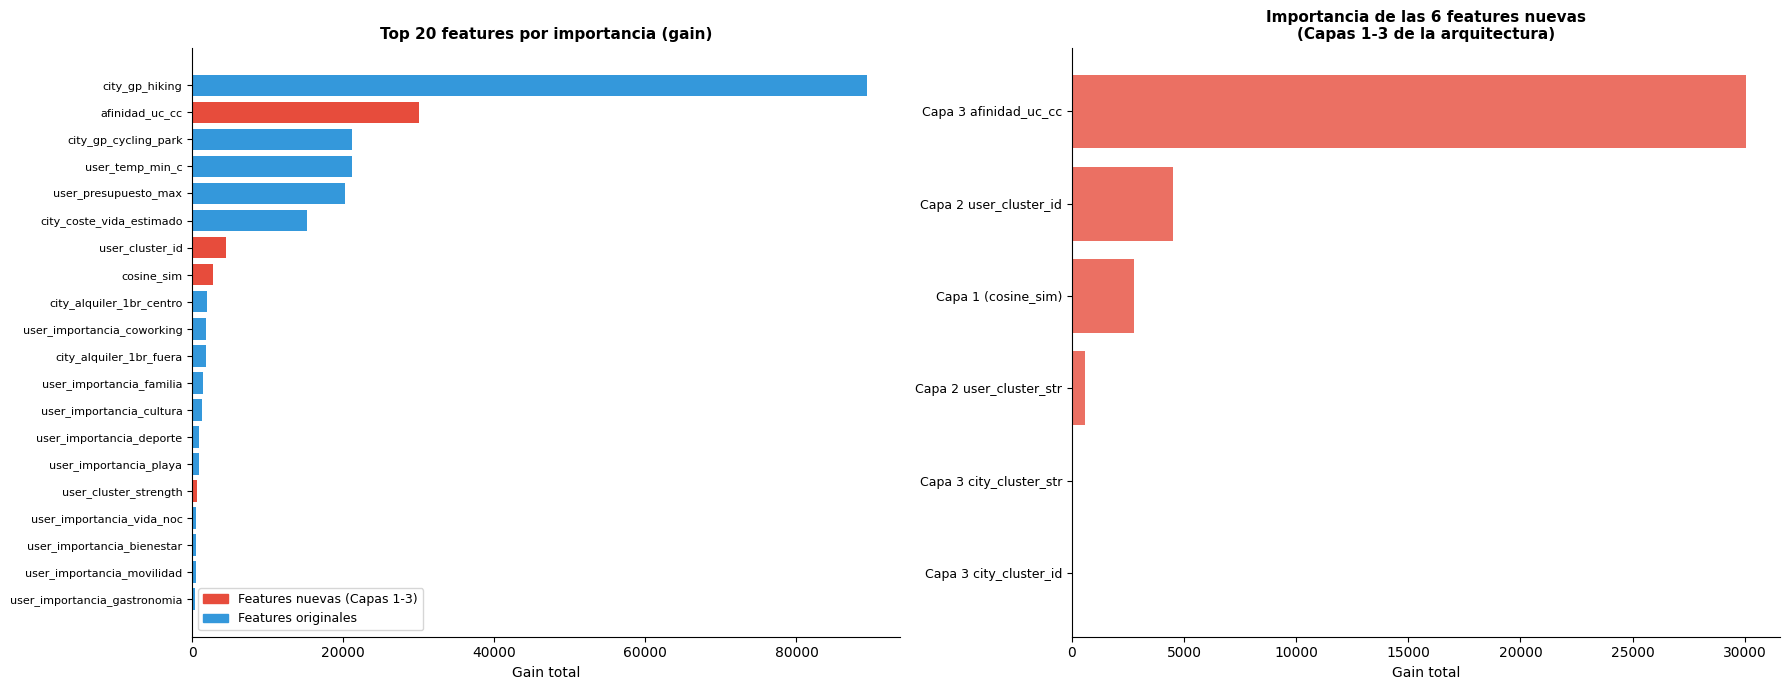

Guardado: lgbm_v2_feature_importance.png


In [13]:
# Visualizacion: comparativa importancia features nuevas vs top features originales

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Izquierda: top 20 features
ax = axes[0]
top20 = importance_gain.head(20)
colors_bar = ['#E74C3C' if f in new_features else '#3498DB' for f in top20.index]
ax.barh(range(len(top20)), top20.values[::-1], color=colors_bar[::-1])
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], fontsize=8)
ax.set_title('Top 20 features por importancia (gain)', fontsize=11, fontweight='bold')
ax.set_xlabel('Gain total')
red_patch  = mpatches.Patch(color='#E74C3C', label='Features nuevas (Capas 1-3)')
blue_patch = mpatches.Patch(color='#3498DB', label='Features originales')
ax.legend(handles=[red_patch, blue_patch], fontsize=9)

# Derecha: importancia por capa
ax2 = axes[1]
capa_imp = {
    'Capa 1 (cosine_sim)': importance_gain.get('cosine_sim', 0),
    'Capa 2 user_cluster_id': importance_gain.get('user_cluster_id', 0),
    'Capa 2 user_cluster_str': importance_gain.get('user_cluster_strength', 0),
    'Capa 3 city_cluster_id': importance_gain.get('city_cluster_id', 0),
    'Capa 3 city_cluster_str': importance_gain.get('city_cluster_strength', 0),
    'Capa 3 afinidad_uc_cc': importance_gain.get('afinidad_uc_cc', 0),
}
capa_series = pd.Series(capa_imp).sort_values(ascending=True)
ax2.barh(range(len(capa_series)), capa_series.values, color='#E74C3C', alpha=0.8)
ax2.set_yticks(range(len(capa_series)))
ax2.set_yticklabels(capa_series.index, fontsize=9)
ax2.set_title('Importancia de las 6 features nuevas\n(Capas 1-3 de la arquitectura)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Gain total')

plt.tight_layout()
plt.savefig('../data/processed/lgbm_v2_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()
print('Guardado: lgbm_v2_feature_importance.png')


---
## Paso 10: Registrar experimento en MLflow

In [14]:
# Paso 10: Registrar el experimento v2 en MLflow
#
# Así podemos comparar v1 (84 features) vs v2 (90 features)
# en la UI de MLflow: mlflow ui → http://127.0.0.1:5000

mlflow.set_experiment('NomadOptima_LightGBM_Ranker')

with mlflow.start_run(run_name='lgbm_ranker_v2_90features') as run:
    mlflow.log_params({
        'objective':          PARAMS['objective'],
        'num_leaves':         PARAMS['num_leaves'],
        'learning_rate':      PARAMS['learning_rate'],
        'n_iteraciones':      model.num_trees(),
        'n_features':         len(FEATURE_COLS),
        'n_features_nuevas':  6,
        'ciudades':           ','.join(df['city'].unique().tolist()),
        'n_train_queries':    len(train_queries),
        'n_val_queries':      len(val_queries),
        'clustering':         'UserClusterer(PCA+UMAP+HDBSCAN) + CityClusterer(manual)',
        'n_user_clusters':    user_clust.n_clusters,
        'n_city_clusters':    3,
    })
    mlflow.log_metrics({
        'ndcg_at_1': ndcg_1, 'ndcg_at_2': ndcg_2,
        'ndcg_at_5': ndcg_5, 'precision_at_1': prec_1,
    })
    mlflow.lightgbm.log_model(model, artifact_path='lgbm_ranker_v2')
    for png in [
        '../data/processed/lgbm_v2_feature_importance.png',
        '../data/processed/umap_clusters.png',
    ]:
        if os.path.exists(png): mlflow.log_artifact(png)
    run_id = run.info.run_id

print('=' * 55)
print('EXPERIMENTO v2 REGISTRADO EN MLFLOW')
print('=' * 55)
print(f'  Run ID  : {run_id}')
print(f'  NDCG@1  : {ndcg_1:.4f}')
print(f'  NDCG@2  : {ndcg_2:.4f}')
print(f'  NDCG@5  : {ndcg_5:.4f}')
print(f'  P@1     : {prec_1:.4f}')
print('  mlflow ui → http://127.0.0.1:5000')


2026/04/06 08:45:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


EXPERIMENTO v2 REGISTRADO EN MLFLOW
  Run ID  : 94219a86f9fd4e6cb1a98f482c215f14
  NDCG@1  : 0.9995
  NDCG@2  : 0.9992
  NDCG@5  : 0.9997
  P@1     : 0.6073
  mlflow ui → http://127.0.0.1:5000


---
## Paso 11: Guardar modelo y artefactos para ranker.py

In [15]:
# Paso 11: Guardar el modelo y artefactos que usará ranker.py
import joblib

MODEL_DIR = '../data/processed/model_v2'
os.makedirs(MODEL_DIR, exist_ok=True)

# Modelo LightGBM
model.save_model(f'{MODEL_DIR}/lgbm_ranker.txt')
print(f'Modelo guardado: {MODEL_DIR}/lgbm_ranker.txt')

# UserClusterer (necesita el scaler, PCA, UMAP y HDBSCAN entrenados)
joblib.dump(user_clust, f'{MODEL_DIR}/user_clusterer.joblib')
print(f'UserClusterer guardado: {MODEL_DIR}/user_clusterer.joblib')

# CityClusterer (solo el mapa manual, pero lo guardamos para consistencia)
joblib.dump(city_clust, f'{MODEL_DIR}/city_clusterer.joblib')
print(f'CityClusterer guardado: {MODEL_DIR}/city_clusterer.joblib')

# CityFeatureBuilder (scaler ajustado con el training set)
joblib.dump(builder, f'{MODEL_DIR}/feature_builder.joblib')
print(f'CityFeatureBuilder guardado: {MODEL_DIR}/feature_builder.joblib')

# Lista de features (para asegurar que inference usa el mismo orden)
with open(f'{MODEL_DIR}/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)
print(f'Feature list guardada: {MODEL_DIR}/feature_cols.json')

print()
print('Todos los artefactos listos para ranker.py')


Modelo guardado: ../data/processed/model_v2/lgbm_ranker.txt


UserClusterer guardado: ../data/processed/model_v2/user_clusterer.joblib
CityClusterer guardado: ../data/processed/model_v2/city_clusterer.joblib
CityFeatureBuilder guardado: ../data/processed/model_v2/feature_builder.joblib
Feature list guardada: ../data/processed/model_v2/feature_cols.json

Todos los artefactos listos para ranker.py


---
## Resumen

In [16]:
print('=' * 60)
print('RESUMEN — NOTEBOOK 04: LIGHTGBM CON ARQUITECTURA COMPLETA')
print('=' * 60)
print()
print('DATASET')
print(f'  Filas         : 150.000')
print(f'  Features      : {len(FEATURE_COLS)} (84 originales + 6 nuevas de Capas 1-3)')
print(f'  Ciudades      : 5 (Malaga, Paris, Valencia, Porto, Bordeaux)')
print()
print('CLUSTERING')
print(f'  User clusters : {user_clust.n_clusters} (PCA->UMAP->HDBSCAN)')
print(f'  City clusters : 3 (manual: mediterraneo/atlantico/metropoli)')
print()
print('MODELO')
print(f'  Tipo          : LightGBM LambdaRank')
print(f'  Arboles       : {model.num_trees()}')
print()
print('METRICAS')
print(f'  NDCG@1        : {ndcg_1:.4f}  (baseline: 0.9986)')
print(f'  NDCG@2        : {ndcg_2:.4f}  (baseline: 0.9981)')
print(f'  NDCG@5        : {ndcg_5:.4f}')
print(f'  Precision@1   : {prec_1:.4f}  (baseline: 0.5913)')
print()
print('ARTEFACTOS')
print(f'  data/processed/model_v2/lgbm_ranker.txt')
print(f'  data/processed/model_v2/user_clusterer.joblib')
print(f'  data/processed/model_v2/city_clusterer.joblib')
print(f'  data/processed/model_v2/feature_builder.joblib')
print()
print('SIGUIENTE PASO: src/models/ranker.py')
print('  Clase NomadRanker que carga estos artefactos y expone')
print('  rank(user_profile) -> lista de ciudades ordenadas')


RESUMEN — NOTEBOOK 04: LIGHTGBM CON ARQUITECTURA COMPLETA

DATASET
  Filas         : 150.000
  Features      : 90 (84 originales + 6 nuevas de Capas 1-3)
  Ciudades      : 5 (Malaga, Paris, Valencia, Porto, Bordeaux)

CLUSTERING
  User clusters : 22 (PCA->UMAP->HDBSCAN)
  City clusters : 3 (manual: mediterraneo/atlantico/metropoli)

MODELO
  Tipo          : LightGBM LambdaRank
  Arboles       : 32

METRICAS
  NDCG@1        : 0.9995  (baseline: 0.9986)
  NDCG@2        : 0.9992  (baseline: 0.9981)
  NDCG@5        : 0.9997
  Precision@1   : 0.6073  (baseline: 0.5913)

ARTEFACTOS
  data/processed/model_v2/lgbm_ranker.txt
  data/processed/model_v2/user_clusterer.joblib
  data/processed/model_v2/city_clusterer.joblib
  data/processed/model_v2/feature_builder.joblib

SIGUIENTE PASO: src/models/ranker.py
  Clase NomadRanker que carga estos artefactos y expone
  rank(user_profile) -> lista de ciudades ordenadas
